#### Gruppe: Brand Innovators


## Oppgave 1: Populasjonsvekst 

##### I denne oppgaven modellererer vi populasjonsveksten for Måløy basert på tilgjengelig data, kvalifiserte gjetninger, og matematiske prinsipper.


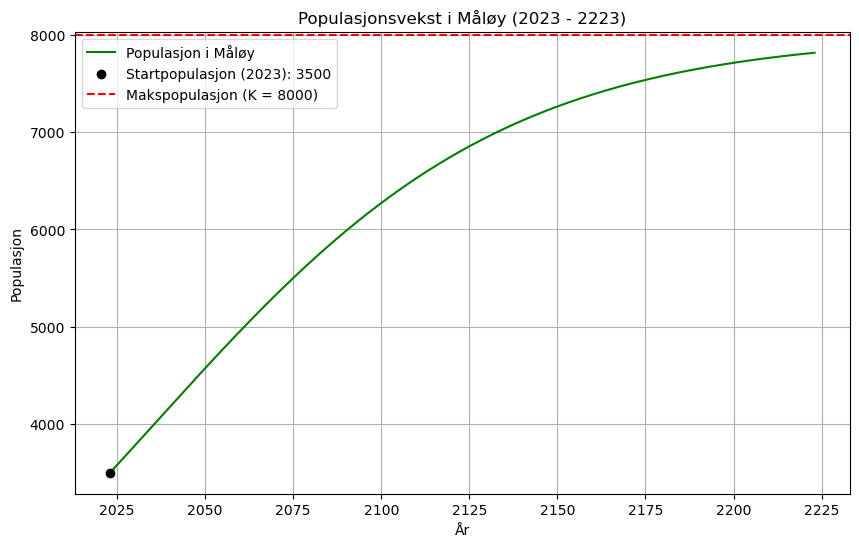

Sluttpopulasjon (i 2223): 7815.94 personer
Total vekst i populasjonen (2023–2223): 4315.94 personer
Absolutt vekst i prosent: 123.31%


In [32]:
#### import numpy as np
import matplotlib.pyplot as plt

# Parametere for den logistiske vekstmodellen
P0 = 3500  # Startpopulasjon
K = 8000   # Makspopulasjon (bæreevne)
r = 0.02   # Vekstrate (2%)
aar = np.arange(2023, 2224)  # Tid fra 2023 til 2223, altså 200 år 
t = aar - 2023  # Tid i år fra 2023

# Logistisk vekstmodell-funksjon
def logistisk_vekst(t, P0, K, r):
    return K / (1 + ((K - P0) / P0) * np.exp(-r * t))

# Beregne populasjonen over tidsperioden
populasjon = logistisk_vekst(t, P0, K, r)

# Plot populasjonsvekst
plt.figure(figsize=(10, 6))
plt.plot(aar, populasjon, label="Populasjon i Måløy", color='green')
plt.scatter(2023, P0, color='black', zorder=5, label=f"Startpopulasjon (2023): {P0}")
plt.title("Populasjonsvekst i Måløy (2023 - 2223)")
plt.xlabel("År")
plt.ylabel("Populasjon")
plt.grid(True)
plt.axhline(y=K, color='red', linestyle='--', label="Makspopulasjon (K = 8000)")
plt.legend()
plt.show()

# Beregninger
sluttpopulasjon = populasjon [-1]
total_vekst = sluttpopulasjon - P0
absolutt_vekst = (total_vekst / P0) * 100

# Skriv ut nyttige resultater
print(f"Sluttpopulasjon (i 2223): {sluttpopulasjon:.2f} personer")
print(f"Total vekst i populasjonen (2023–2223): {total_vekst:.2f} personer")
print(f"Absolutt vekst i prosent: {absolutt_vekst:.2f}%")

## Oppgave 2: Sparekalkulator

### Introduksjon

Denne koden beregner og modellerer sluttbeløpet ved sparing over en tidsperiode, med månedlige innskudd og renters rente. Modellen tar hensyn til flere faktorer som inflasjon, skatt på renteinntekter og formueskatt, for å gi et realistisk bilde av hvordan sparepengene utvikler seg over tid.

Formelen for å beregne sluttbeløpet med renters rente er som følger:

$$
F = P \times \frac{{(1 + \frac{r}{n})^{nt} - 1}}{{\frac{r}{n}}}
$$

Hvor:
- **A**: Sluttbeløpet etter spart tid.
- **P**: Terminbeløp (månedlig innskudd).
- **r**: Årlig rente (i desimalform).
- **n**: Antall innskudd/renteavregninger per år.
- **t**: Antall år spart.

Koden inkluderer:
- Beregning av sluttbeløp ved hjelp av renters rente.
- Justering for inflasjon for å beregne den reelle verdien av pengene ved spareperiodens slutt.
- Beregning av skatt på renteinntekter og formueskatt.
- En grafisk fremstilling av beløpsutviklingen over tid.

Skriv inn terminbeløp:  1500
Skriv inn årlig rente (i prosent):  2
Skriv inn antall innskudd/renteavregninger per år:  12
Skriv inn antall år du skal spare:  10



Sluttbeløp: 199079.49 kr
Total innskudd: 180000.00 kr
Renter: 19079.49 kr
Innskudd utgjør 90.42% av sluttbeløpet
Renter utgjør 9.58% av sluttbeløpet



Inkludere inflasjon og skatt (ja/nei)?  ja
Skriv inn årlig inflasjon i prosent:  3.5
Skriv inn skatt i prosent:  22
Skriv inn formueskatt i prosent:  1


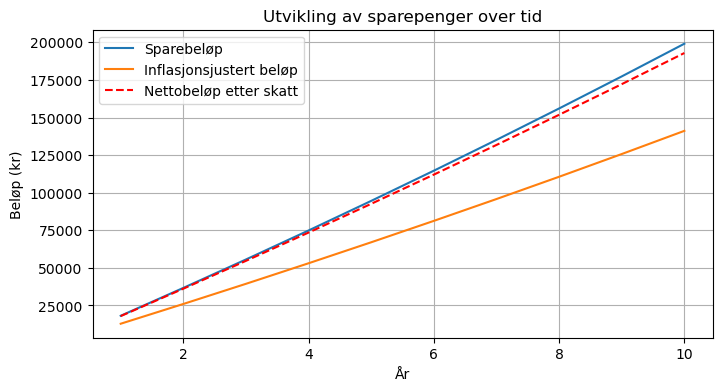

In [34]:
import matplotlib.pyplot as plt

# Funksjon for å hente brukerinput og returnere en dictionary
def hent_input():
    P = float(input("Skriv inn terminbeløp: "))
    r = float(input("Skriv inn årlig rente (i prosent): ")) / 100  # Omgjør fra prosent til desimal
    n = int(input("Skriv inn antall innskudd/renteavregninger per år: "))
    t = float(input("Skriv inn antall år du skal spare: "))
    return {"P": P, "r": r, "n": n, "t": t}

# Funksjon for å beregne sluttbeløp, total innskudd og renter
def beregn_sluttbelop(data):
    P, r, n, t = data["P"], data["r"], data["n"], data["t"]
    sluttbeløp = P * (((1 + r / n) ** (n * t) - 1) / (r / n))
    total_innskudd = P * n * t
    renter = sluttbeløp - total_innskudd
    return sluttbeløp, total_innskudd, renter

# Funksjon for å skrive ut resultater
def skriv_ut_resultater(sluttbelop, total_innskudd, renter):
    renter_prosent = (renter / sluttbelop) * 100
    innskudd_prosent = (total_innskudd / sluttbelop) * 100
    print(f"\nSluttbeløp: {sluttbelop:.2f} kr")
    print(f"Total innskudd: {total_innskudd:.2f} kr")
    print(f"Renter: {renter:.2f} kr")
    print(f"Innskudd utgjør {innskudd_prosent:.2f}% av sluttbeløpet")
    print(f"Renter utgjør {renter_prosent:.2f}% av sluttbeløpet")

# Funksjon for å inkludere inflasjon og skatt
def beregn_med_inflasjon_og_skatt(data, sparebeløp_over_tid, renter_over_tid):
    t = data["t"]
    inflasjon = float(input("Skriv inn årlig inflasjon i prosent: ")) / 100
    skatt_renteinntekter = float(input("Skriv inn skatt i prosent: ")) / 100
    formueskatt = float(input("Skriv inn formueskatt i prosent: ")) / 100
    
    inflasjonsjustert_over_tid = []
    nettobelop_over_tid = []
    
    for sluttbelop, renter in zip(sparebeløp_over_tid, renter_over_tid):
        inflasjonsjustert_F = sluttbelop / ((1 + inflasjon) ** t)
        skatt = renter * skatt_renteinntekter
        netto_beløp = sluttbelop - skatt - (sluttbelop * formueskatt)
        inflasjonsjustert_over_tid.append(inflasjonsjustert_F)
        nettobelop_over_tid.append(netto_beløp)

    return inflasjonsjustert_over_tid, nettobelop_over_tid  # Returnerer verdier for plotting

# Funksjon for å plotte utviklingen
def plot_utvikling(tidsperioder, sparebeløp_over_tid, inflasjonsjustert_over_tid, nettobelop_over_tid):
    plt.figure(figsize=(8, 4))  # Setter størrelsen på figuren til 8x4 tommer
    plt.plot(tidsperioder, sparebeløp_over_tid, label="Sparebeløp")
    plt.plot(tidsperioder, inflasjonsjustert_over_tid, label="Inflasjonsjustert beløp")
    plt.plot(tidsperioder, nettobelop_over_tid, label="Nettobeløp etter skatt", linestyle="--", color="red")

    plt.title("Utvikling av sparepenger over tid")
    plt.xlabel("År")
    plt.ylabel("Beløp (kr)")
    plt.legend()
    plt.grid(True)
    plt.show()

# Hovedfunksjon for å kjøre kalkulatoren
def sparekalkulator():
    data = hent_input()
    sluttbeløp, total_innskudd, renter = beregn_sluttbelop(data)
    skriv_ut_resultater(sluttbeløp, total_innskudd, renter)

    tidsperioder = [i for i in range(1, int(data['t']) + 1)]
    sparebeløp_over_tid = [data["P"] * (((1 + data["r"] / data["n"]) ** (data["n"] * år) - 1) / (data["r"] / data["n"])) for år in tidsperioder]
    renter_over_tid = [belop - (data["P"] * data["n"] * år) for belop, år in zip(sparebeløp_over_tid, tidsperioder)]

    if input("\nInkludere inflasjon og skatt (ja/nei)? ").lower() == 'ja':
        inflasjonsjustert_over_tid, nettobelop_over_tid = beregn_med_inflasjon_og_skatt(data, sparebeløp_over_tid, renter_over_tid)
    else:
        inflasjonsjustert_over_tid = sparebeløp_over_tid
        nettobelop_over_tid = sparebeløp_over_tid
    
    plot_utvikling(tidsperioder, sparebeløp_over_tid, inflasjonsjustert_over_tid, nettobelop_over_tid)

# Kjører sparekalkulatoren
sparekalkulator()


### Oppgave 3: Varer på salg

##### I denne oppgaven simulerer vi hvordan det å sette varer på salg påvirker butikkens salg og omsetning. Målet er å sammenligne 
##### forskjelene i salg over en periode med og uten produkter på tilbud. Dette vil gi innsikt i hvor stor påvirkning prisereduksjon har
##### på kundeadferd og den totale omsetningen.


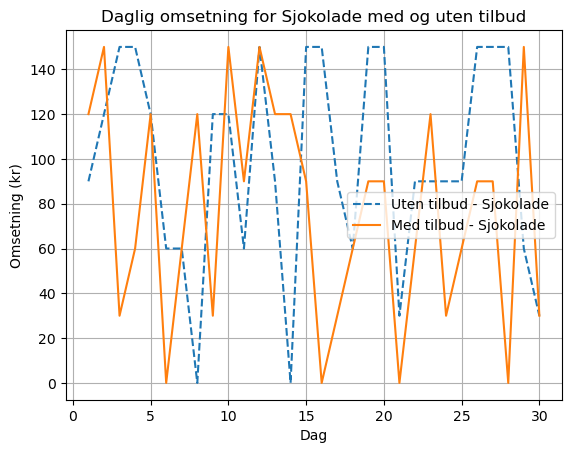

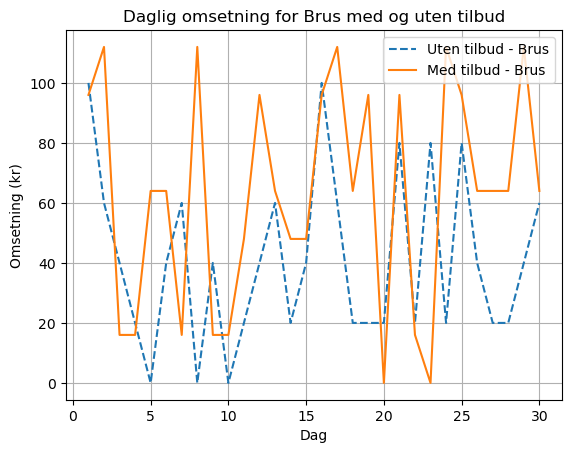

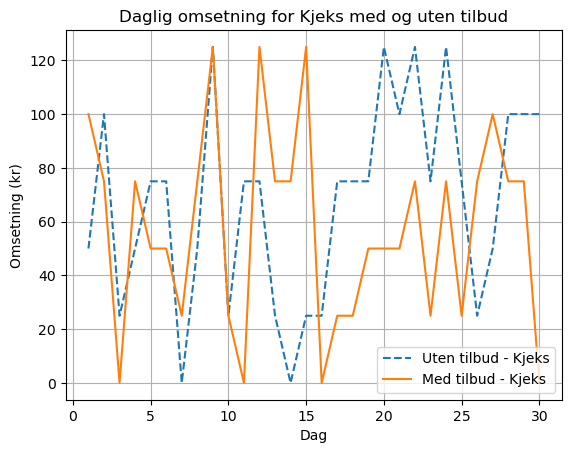

Total omsetning uten tilbud:
Sjokolade: 2970.00 kr
Brus: 1220.00 kr
Kjeks: 2025.00 kr

Total omsetning med tilbud på Brus:
Sjokolade: 2310.00 kr
Brus: 1888.00 kr
Kjeks: 1725.00 kr

Differanse i omsetning med og uten tilbud:
Sjokolade: -660.00 kr
Brus: 668.00 kr
Kjeks: -300.00 kr


In [18]:
import random
import matplotlib.pyplot as plt

# Definere tre produkter og deres normale priser
produkter = {
    'Sjokolade': 30,
    'Brus': 20,
    'Kjeks': 25
}

# Antall dager vi vil simulere salg for
antall_dager = 30
base_kunder_per_dag = 100  # Gjennomsnittlig antall kunder per dag
tilbuds_multiplikator = 1.5  # Hvor mye mer kunder kjøper ved tilbud

# Funksjon for å simulere salg uten tilbud
def simuler_salg_uten_tilbud():
    daglig_omsetning_per_produkt = {produkt: [] for produkt in produkter}
    for dag in range(antall_dager):
        kunder = random.randint(base_kunder_per_dag - 10, base_kunder_per_dag + 10)
        for produkt, pris in produkter.items():
            solgte_enheter = random.randint(1, 5) * kunder // 100  # En liten prosentandel kjøper hvert produkt
            daglig_omsetning_per_produkt[produkt].append(solgte_enheter * pris)
    return daglig_omsetning_per_produkt

# Funksjon for å simulere salg med tilbud på ett produkt
def simuler_salg_med_tilbud(tilbuds_produkt, rabatt_prosent):
    daglig_omsetning_per_produkt = {produkt: [] for produkt in produkter}
    for dag in range(antall_dager):
        kunder = random.randint(base_kunder_per_dag - 10, base_kunder_per_dag + 10)
        for produkt, pris in produkter.items():
            solgte_enheter = random.randint(1, 5) * kunder // 100
            
            # Hvis produktet er på tilbud, øker vi salget og reduserer prisen
            if produkt == tilbuds_produkt:
                solgte_enheter = int(solgte_enheter * tilbuds_multiplikator)
                pris *= (1 - rabatt_prosent / 100)
            
            daglig_omsetning_per_produkt[produkt].append(solgte_enheter * pris)
    return daglig_omsetning_per_produkt

# Simuler salg
omsetning_uten_tilbud = simuler_salg_uten_tilbud()
omsetning_med_tilbud = simuler_salg_med_tilbud('Brus', 20)  # Sett 'Brus' på tilbud med 20% rabatt

# Plotting av omsetning over tid for hvert produkt i separate grafer
dager = list(range(1, antall_dager + 1))

for produkt in produkter:
    plt.figure()  # Opprett ny figur for hvert produkt
    plt.plot(dager, omsetning_uten_tilbud[produkt], label=f'Uten tilbud - {produkt}', linestyle='--')
    plt.plot(dager, omsetning_med_tilbud[produkt], label=f'Med tilbud - {produkt}')
    
    plt.title(f'Daglig omsetning for {produkt} med og uten tilbud')
    plt.xlabel('Dag')
    plt.ylabel('Omsetning (kr)')
    plt.legend()
    plt.grid(True)
    plt.show()

# Beregning av total omsetning
total_omsetning_uten_tilbud = {produkt: sum(omsetning_uten_tilbud[produkt]) for produkt in produkter}
total_omsetning_med_tilbud = {produkt: sum(omsetning_med_tilbud[produkt]) for produkt in produkter}

print("Total omsetning uten tilbud:")
for produkt, omsetning in total_omsetning_uten_tilbud.items():
    print(f"{produkt}: {omsetning:.2f} kr")

print("\nTotal omsetning med tilbud på Brus:")
for produkt, omsetning in total_omsetning_med_tilbud.items():
    print(f"{produkt}: {omsetning:.2f} kr")

# Differanse for hvert produkt
differanse = {produkt: total_omsetning_med_tilbud[produkt] - total_omsetning_uten_tilbud[produkt] for produkt in produkter}
print("\nDifferanse i omsetning med og uten tilbud:")
for produkt, diff in differanse.items():
    print(f"{produkt}: {diff:.2f} kr")
